# Classifying Penguins with Keras Day 2

In [1]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

import matplotlib.pyplot as plt

C:\miniforge3\envs\machine-learning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
keras.utils.clear_session(free_memory=True)

In [4]:
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [5]:
# drop Nan rows
penguins.dropna(inplace=True)

In [6]:
# defining X
penguins_x = pd.concat([penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']], pd.get_dummies(penguins['sex'])], axis = 1)
# penguins_x = penguins_x[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'female', 'male']]

# defining y
penguins_y = penguins['species']
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()

# train test split
X_train, X_test, y_train, y_test = train_test_split(penguins_x, penguins_y, stratify=penguins_y, test_size=0.2, random_state=42)

In [7]:
# Scaling the data
scalar = StandardScaler().set_output(transform="pandas")

# fit the scaler on the training data and transform both training and test data
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

X_train_scaled

,body_mass_g,bill_length_mm,bill_depth_mm,flipper_length_mm,female,male
200,1.082394,0.167325,-1.992311,0.834781,1.046178,-1.046178
329,-0.215642,1.227050,1.255521,0.121247,-0.955860,0.955860
269,2.194997,0.879899,-0.520638,1.476961,-0.955860,0.955860
123,-0.431982,-0.472164,0.646552,0.049894,-0.955860,0.955860
38,-1.142811,-1.166467,1.052531,-1.448527,1.046178,-1.046178
...,...,...,...,...,...,...
24,-0.524699,-0.947213,-0.013164,-1.519881,-0.955860,0.955860
325,-0.679227,1.062610,0.037584,-0.235520,1.046178,-1.046178
43,0.217037,0.021156,1.255521,-0.378227,-0.955860,0.955860
187,1.453262,0.806814,-0.469890,1.334255,-0.955860,0.955860


### Defining the model

In [8]:
# construct the model
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation='relu')(inputs)
x = layers.Dense(5, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model") # random weights are initialized here

In [9]:
model.summary()

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107 (428.00 B)

 Trainable params: 107 (428.00 B)

 Non-trainable params: 0 (0.00 B)

### Model training parameters (compile) & model training (fit)

In [10]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size=128,
                    epochs=10, 
                    validation_split=0.2, 
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 335ms/step - accuracy: 0.1509 - loss: 1.1448 - val_accuracy: 0.1296 - val_loss: 1.1410
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.1462 - loss: 1.1365 - val_accuracy: 0.1852 - val_loss: 1.1323
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.1604 - loss: 1.1289 - val_accuracy: 0.1852 - val_loss: 1.1238
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.1840 - loss: 1.1212 - val_accuracy: 0.2222 - val_loss: 1.1157
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.1934 - loss: 1.1134 - val_accuracy: 0.2037 - val_loss: 1.1080
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2123 - loss: 1.1064 - val_accuracy: 0.2222 - val_loss: 1.1004
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.2170 - loss: 1.0998 - val_accuracy: 0.2963 - val_loss: 1.0931
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2406 - loss: 1.0928 - val_accuracy: 0.2963 - val_loss: 1.0860

### Evaluating on the test data

In [27]:
# evaluate the model using the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1) 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')

print("\n Test Set Evaluation:") 
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000273825191C0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

 Test Set Evaluation:
Test Accuracy: 0.2687
Test Precision: 0.1172
Test Recall: 0.2687
Test F1 Score: 0.1632
Test ROC AUC Score: 0.4170


### Evaluating model training using loss and accuracy

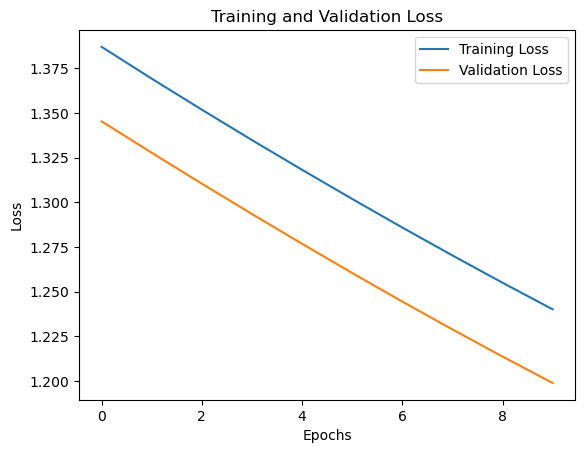

In [28]:
# plot loss vs val_loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

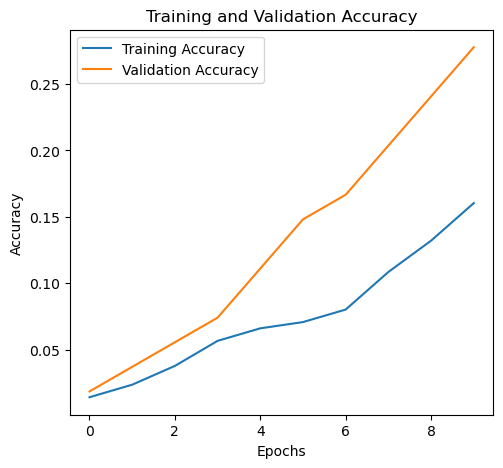

In [29]:
# plot the training and validation accuracy
plt.figure(figsize=(12, 5))     
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()    

### Model variability

Define, compile and train the model 3 times and see how your training and validation curves change. Are they the same or different? Why is this happening?

> Curves are super different for each model. This is because when we call `model.compile()` without a random seed specified earlier, the initial weights are completely different for each neuron.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2090 - loss: 1.1581 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5075 - loss: 0.9281 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4627 - loss: 0.9640 


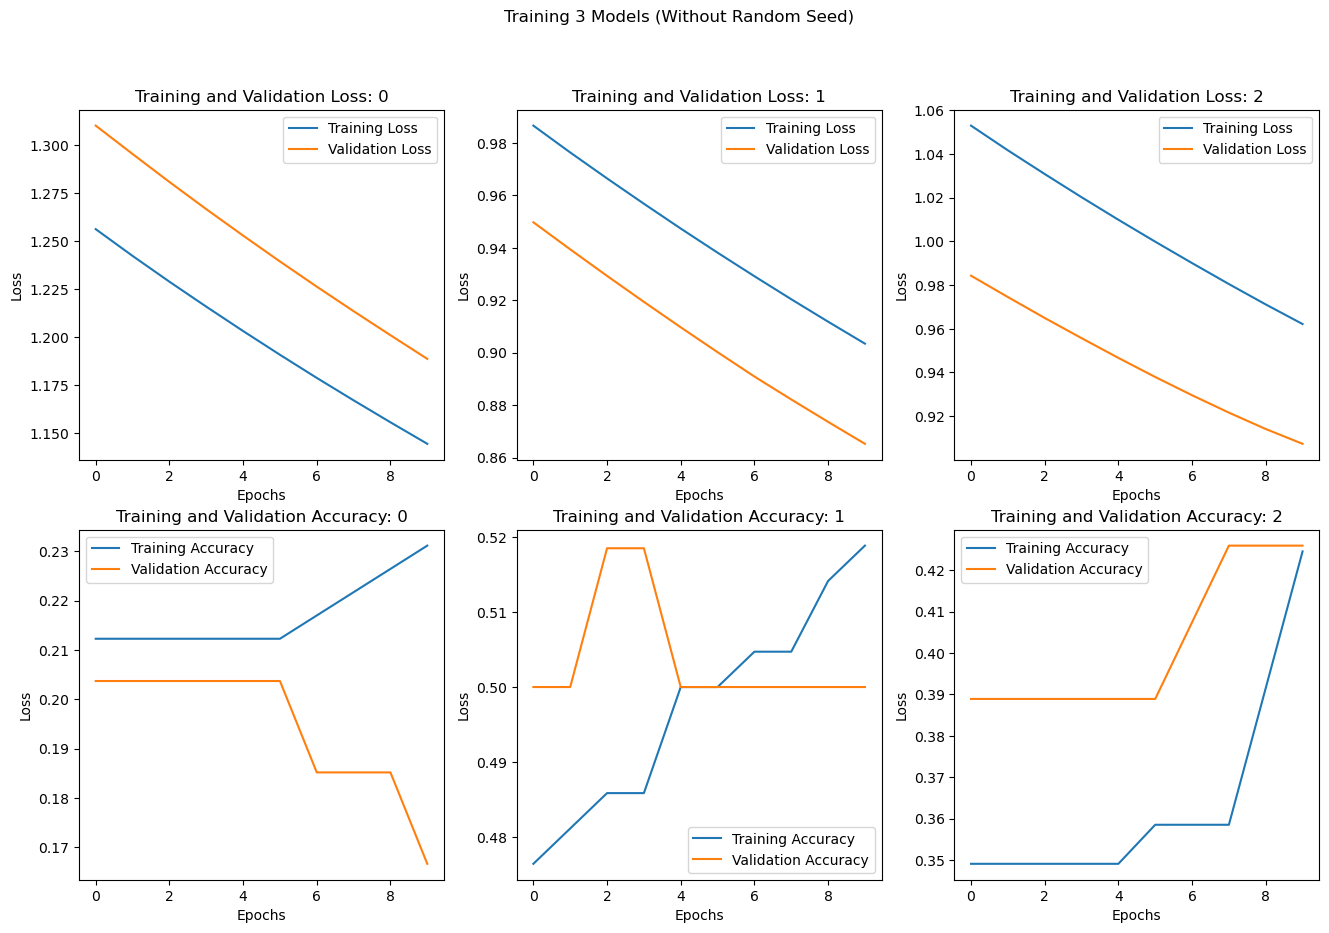

In [65]:
fig, axes = plt.subplots(figsize=(16, 10), nrows=2, ncols=3)
fig.suptitle("Training 3 Models (Without Random Seed)")

for i in range(3):
    # clear cache
    keras.utils.clear_session(free_memory=True)

    # define
    inputs = keras.Input(shape=(6,))
    x = layers.Dense(7, activation='relu')(inputs)
    x = layers.Dense(5, activation='relu')(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

    # compile
    model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
    )

    # train & eval
    history = model.fit(X_train_scaled, y_train,
                    batch_size=128,
                    epochs=10,
                    validation_split=0.2,
                    verbose=0)

    scores = model.evaluate(X_test_scaled, y_test, verbose=1)

    # plot loss & acc
    axes[0, i].plot(history.history['loss'], label='Training Loss')
    axes[0, i].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, i].set_xlabel('Epochs')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].set_title(f'Training and Validation Loss: {i}')
    axes[0, i].legend()

    axes[1, i].plot(history.history['accuracy'], label='Training Accuracy')
    axes[1, i].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1, i].set_xlabel('Epochs')
    axes[1, i].set_ylabel('Loss')
    axes[1, i].set_title(f'Training and Validation Accuracy: {i}')
    axes[1, i].legend()

plt.show()

### Setting a random seed

How does setting the tf random seed affect the training and validation curves?

> The general patterns are now the same (increasing accuracy and mostly parallel loss curves) but there is still some variability.

Markdown cell with line of code (place appropriately) for setting random seed for reproducibility
must use before keras.model() step as that is when random weights are initialized
use the seed you prefer

tf.random.set_seed(42)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2687 - loss: 1.2252 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4030 - loss: 1.0312 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6269 - loss: 0.9413 


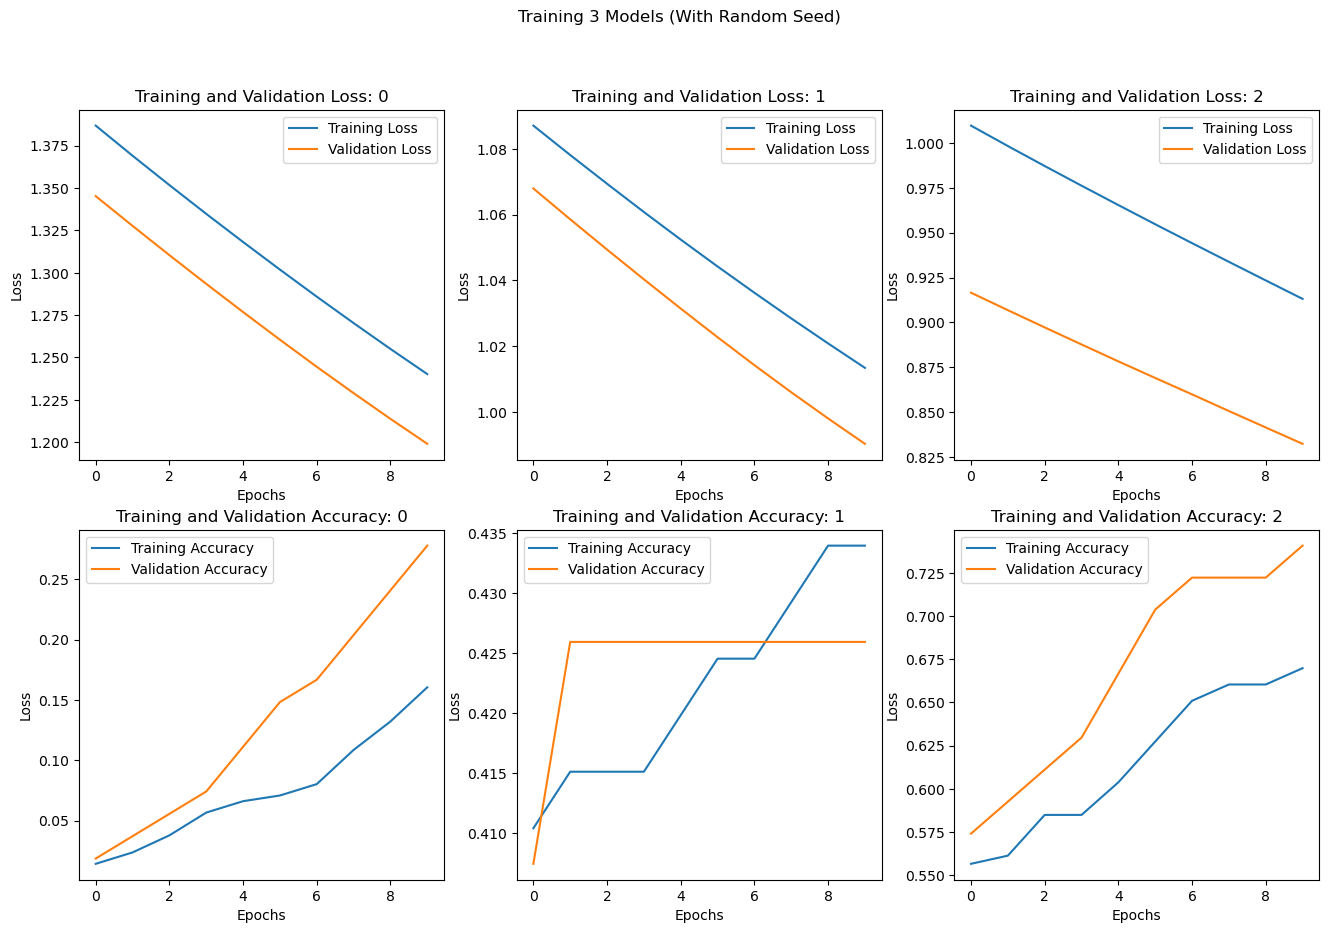

In [64]:
keras.utils.set_random_seed(42) # set all random seeds (numpy, tf, random)

fig, axes = plt.subplots(figsize=(16, 10), nrows=2, ncols=3)

fig.suptitle("Training 3 Models (With Random Seed)")

for i in range(3):
    # clear cache
    keras.utils.clear_session(free_memory=True)

    # define
    inputs = keras.Input(shape=(6,))
    x = layers.Dense(7, activation='relu')(inputs)
    x = layers.Dense(5, activation='relu')(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

    # compile
    model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
    )

    # train & eval
    history = model.fit(X_train_scaled, y_train,
                    batch_size=128,
                    epochs=10,
                    validation_split=0.2,
                    verbose=0)

    scores = model.evaluate(X_test_scaled, y_test, verbose=1)

    # plot loss & acc
    axes[0, i].plot(history.history['loss'], label='Training Loss')
    axes[0, i].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, i].set_xlabel('Epochs')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].set_title(f'Training and Validation Loss: {i}')
    axes[0, i].legend()

    axes[1, i].plot(history.history['accuracy'], label='Training Accuracy')
    axes[1, i].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1, i].set_xlabel('Epochs')
    axes[1, i].set_ylabel('Loss')
    axes[1, i].set_title(f'Training and Validation Accuracy: {i}')
    axes[1, i].legend()

plt.show()

### Modifying the hidden layers

Try **three** different configurations for the hidden layers. You are welcome to add or remove layers, to try different layer strategies (funnel, flat, etc ) and to vary the number of neurons. For each configuration, record: (1) the architecture you tried, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What seemed to work best?

> I tried a funnel, flat, and dropout architecture; each with three layers. The flat model performed best, with a test accuracy of 0.94. The dropout performed worst, with a test accuracy of 0.76.
>
> The funnel model had exponential-decay loss curves, where training loss always stays above validation loss (good; no overfitting). The flat model seemed to overfit a slight amount, with very little margin between both linear loss curves. The dropout model had the most randomness in its loss curves.

In [16]:
# define three different models

# funnel model 32 -> 16 -> 8
inputs = keras.Input(shape=(6,))
x = layers.Dense(32, activation='relu')(inputs)
x = layers.Dense(16, activation='relu')(x)
x = layers.Dense(8, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model_funnel = keras.Model(inputs=inputs, outputs=outputs, name="funnel")

# flat 8 -> 8 -> 8
inputs = keras.Input(shape=(6,))
x = layers.Dense(8, activation='relu')(inputs)
x = layers.Dense(8, activation='relu')(x)
x = layers.Dense(8, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model_flat = keras.Model(inputs=inputs, outputs=outputs, name="flat")

# 0.3 dropout
inputs = keras.Input(shape=(6,))
x = layers.Dense(8, activation="leaky_relu")(inputs)
x = layers.Dropout(0.3)(x)
x = layers.Dense(4, activation="relu")(x)
outputs = layers.Dense(3, activation="softmax")(x)
model_dropout = keras.Model(inputs=inputs, outputs=outputs, name="dropout")

models = [("funnel", model_funnel), ("flat", model_flat), ("dropout", model_dropout)]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8657 - loss: 0.2637
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9403 - loss: 0.4970
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7612 - loss: 0.8496


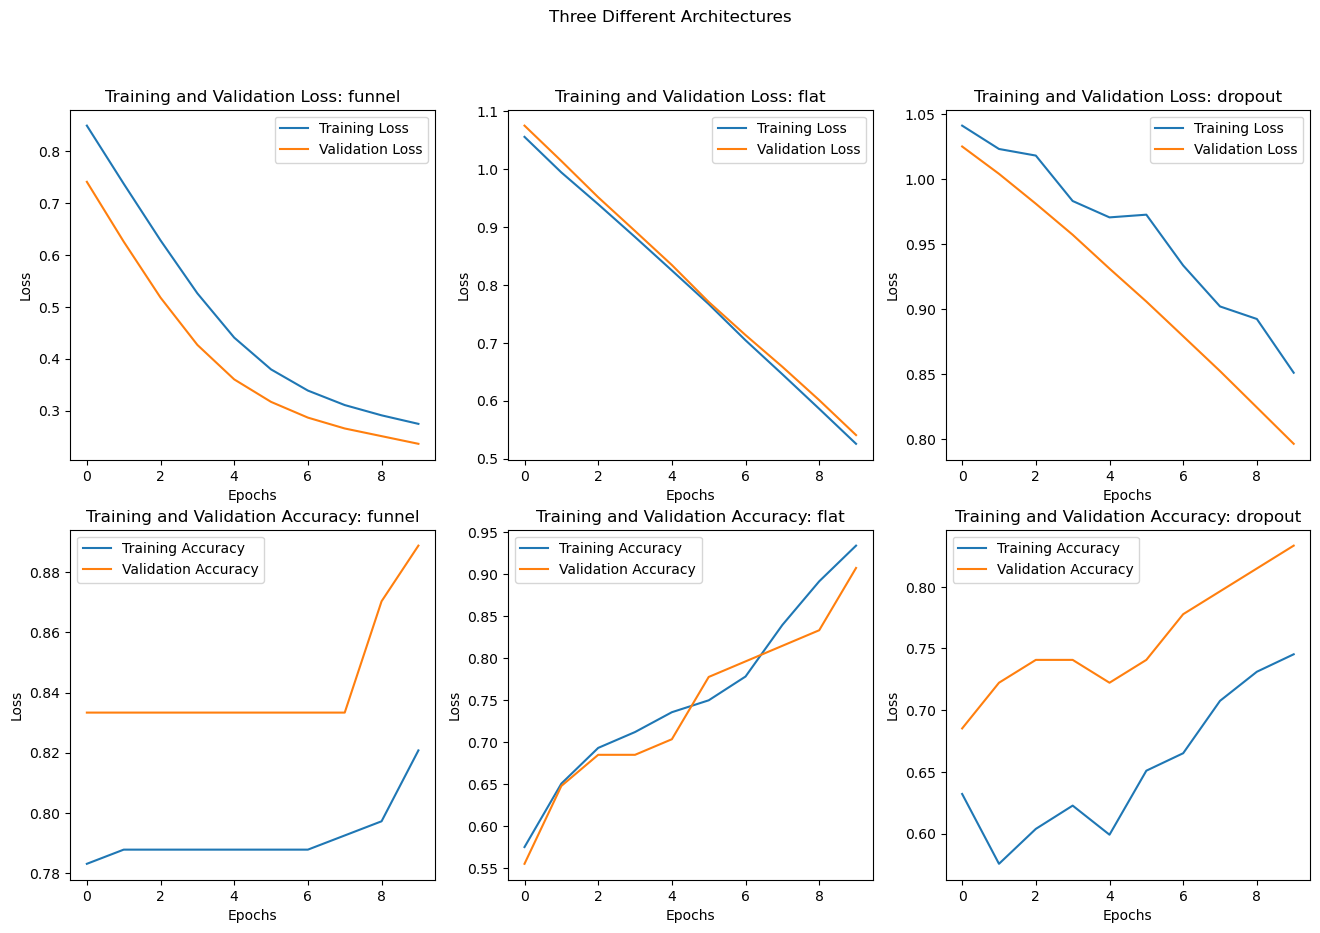

In [18]:
fig, axes = plt.subplots(figsize=(16, 10), nrows=2, ncols=3)
fig.suptitle("Three Different Architectures")

for i, (name, model) in enumerate(models):
    # train the model
    model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"])

    history = model.fit(X_train_scaled, y_train,
                    batch_size=16,
                    epochs=10,
                    validation_split=0.2,
                    verbose=0)

    scores = model.evaluate(X_test_scaled, y_test, verbose=1)

    # plot loss & acc
    axes[0, i].plot(history.history['loss'], label='Training Loss')
    axes[0, i].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, i].set_xlabel('Epochs')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].set_title(f'Training and Validation Loss: {name}')
    axes[0, i].legend()

    axes[1, i].plot(history.history['accuracy'], label='Training Accuracy')
    axes[1, i].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1, i].set_xlabel('Epochs')
    axes[1, i].set_ylabel('Loss')
    axes[1, i].set_title(f'Training and Validation Accuracy: {name}')
    axes[1, i].legend()

### Modifying the training cycles (epochs)

Vary the number of epochs. For each configuration, record: (1) the number of epochs, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What was the minimum number of epochs needed for reliable model performance?

> As we increase the number of epochs, the loss curves are able to sink lower. In general, accuracy vs num epochs seems parabolic: there is an optimal number of epochs where we see improvements before accuracy begins to tank. In this test, the optimal number of epochs is 8.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2687 - loss: 1.2252
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4030 - loss: 1.0312
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6269 - loss: 0.9413 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2090 - loss: 1.1581
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5075 - loss: 0.9281


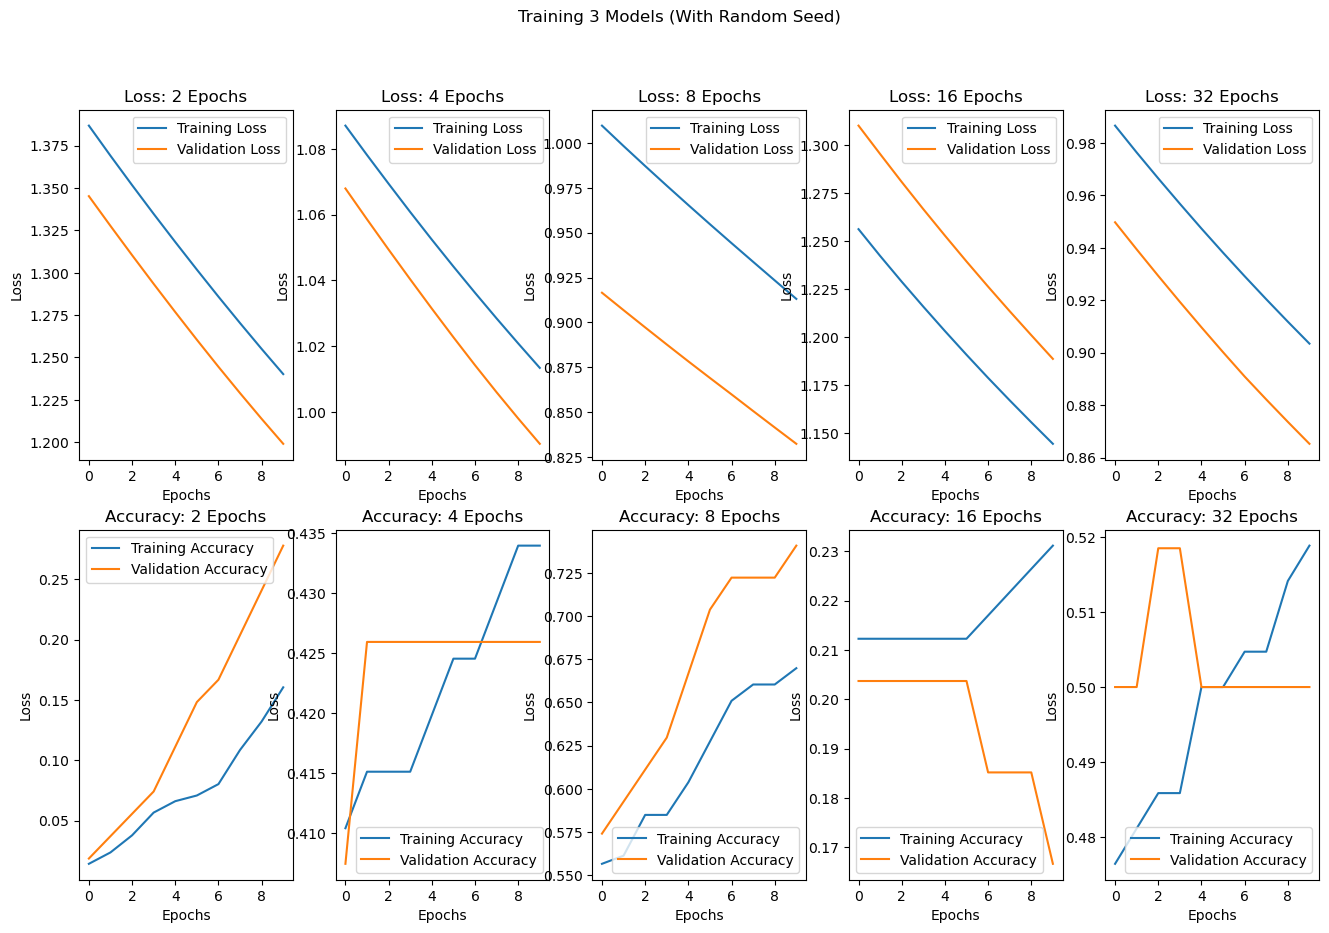

In [23]:
epochs = [2, 4, 8, 16, 32]

keras.utils.set_random_seed(42) # set all random seeds (numpy, tf, random)

fig, axes = plt.subplots(figsize=(16, 10), nrows=2, ncols=5)

fig.suptitle("Training 3 Models (With Random Seed)")

for i, epoch in enumerate(epochs):
    # clear cache
    keras.utils.clear_session(free_memory=True)

    # define
    inputs = keras.Input(shape=(6,))
    x = layers.Dense(7, activation='relu')(inputs)
    x = layers.Dense(5, activation='relu')(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

    # compile
    model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
    )

    # train & eval
    history = model.fit(X_train_scaled, y_train,
                    batch_size=128,
                    epochs=10,
                    validation_split=0.2,
                    verbose=0)

    scores = model.evaluate(X_test_scaled, y_test, verbose=1)

    # plot loss & acc
    axes[0, i].plot(history.history['loss'], label='Training Loss')
    axes[0, i].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, i].set_xlabel('Epochs')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].set_title(f'Loss: {epoch} Epochs')
    axes[0, i].legend()

    axes[1, i].plot(history.history['accuracy'], label='Training Accuracy')
    axes[1, i].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1, i].set_xlabel('Epochs')
    axes[1, i].set_ylabel('Loss')
    axes[1, i].set_title(f'Accuracy: {epoch} Epochs')
    axes[1, i].legend()

plt.show()

### Early stopping, l2 regularization and dropout 

Doing all these for peguins is probably overkill!

In [35]:
# sample model


inputs = keras.Input(shape=(6,))  # 6 input features

x = layers.Dense(
    7,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 penalty on weights
)(inputs)
x = layers.Dropout(0.2)(x)  # randomly drop 20% of neurons during training

x = layers.Dense(
    5,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 applied again
)(x)
x = layers.Dropout(0.2)(x)  # dropout applied per layer

x = layers.Dense(
    3,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 on final hidden layer
)(x)
x = layers.Dropout(0.2)(x)  # dropout again (often not needed this deep)

outputs = layers.Dense(3, activation="softmax")(x)  # 3-class output → probabilities

model = keras.Model(inputs=inputs, outputs=outputs)  # build model (initialize weights)

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # multiclass loss
    optimizer=keras.optimizers.Adam(),  # adaptive optimizer
    metrics=["accuracy"]  # track accuracy
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",  # watch validation loss
    patience=5,  # stop after 5 epochs without improvement
    restore_best_weights=True  # keep best-performing weights
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,  # maximum training length
    batch_size=8,
    validation_split=0.2,  # hold out 10% for validation
    callbacks=[early_stop],  # apply early stopping
    verbose=1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3726 - loss: 1.4926 - val_accuracy: 0.3889 - val_loss: 1.3880
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3821 - loss: 1.3334 - val_accuracy: 0.4259 - val_loss: 1.2214
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4387 - loss: 1.2584 - val_accuracy: 0.6111 - val_loss: 1.0852
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5047 - loss: 1.1394 - val_accuracy: 0.6852 - val_loss: 1.0072
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6179 - loss: 1.0643 - val_accuracy: 0.7407 - val_loss: 0.9478
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6745 - loss: 1.0310 - val_accuracy: 0.8333 - val_loss: 0.9052
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7075 - loss: 1.0182 - val_accuracy: 0.8333 - val_loss: 0.8727
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7217 - loss: 0.9617 - val_accuracy: 0.8333 - 

### Tuning with Optuna

Adjust the code below to have the validation size, epochs and verbosity you found best from above. Then tune your model. You are welcome to increase the number of trials or to add parameters if you desire. Make sure the outputs of your cells are displayed. Then build a final model using your optimized parameters and predict on the test set.

In [36]:
# tuning the model with Optuna
def objective(trial):
    num_layers = trial.suggest_int("num_layers", 1, 3)  # number of hidden layers
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)  # log scale for LR
    batch_size = trial.suggest_categorical("batch_size", [4, 8, 16, 32, 64])  # common batch sizes

    inputs = keras.Input(shape=(6,))  # 6 input features
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 4, 32)  # neurons per layer
        x = layers.Dense(units, activation="relu")(x)  # hidden layer

    outputs = layers.Dense(3, activation="softmax")(x)  # 3 classes → softmax output
    model = keras.Model(inputs=inputs, outputs=outputs)  # build model

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # classification loss
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),  # optimizer with tuned LR
        metrics=["accuracy"],  # track accuracy
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",  # watch validation loss
        patience=5,  # stop after 5 epochs without improvement
        restore_best_weights=True  # keep best model weights
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=batch_size,
        epochs=50,  # max training epochs
        validation_split=0.2,  # validation portion of training data
        verbose=0,  # suppress output during tuning
        callbacks=[early_stop]  # apply early stopping
    )

    return min(history.history["val_loss"])  # objective = best validation loss


study = optuna.create_study(direction="minimize")  # minimize validation loss
study.optimize(objective, n_trials=20)  # run 20 trials (20 models)

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)

[I 2026-05-14 13:23:30,703] A new study created in memory with name: no-name-25626639-b1f8-462b-a4ce-1f1f39073ce6
[I 2026-05-14 13:23:41,669] Trial 0 finished with value: 0.40060922503471375 and parameters: {'num_layers': 2, 'learning_rate': 0.00010404069284226194, 'batch_size': 4, 'num_units_layer_1': 26, 'num_units_layer_2': 8}. Best is trial 0 with value: 0.40060922503471375.
[I 2026-05-14 13:23:45,787] Trial 1 finished with value: 0.0367988646030426 and parameters: {'num_layers': 2, 'learning_rate': 0.008616727473344006, 'batch_size': 32, 'num_units_layer_1': 9, 'num_units_layer_2': 15}. Best is trial 1 with value: 0.0367988646030426.
[I 2026-05-14 13:23:51,463] Trial 2 finished with value: 0.022458484396338463 and parameters: {'num_layers': 3, 'learning_rate': 0.004466557493396511, 'batch_size': 32, 'num_units_layer_1': 22, 'num_units_layer_2': 6, 'num_units_layer_3': 11}. Best is trial 2 with value: 0.022458484396338463.
[I 2026-05-14 13:23:59,458] Trial 3 finished with value: 0.

Best validation loss: 0.022458484396338463
Best parameters: {'num_layers': 3, 'learning_rate': 0.004466557493396511, 'batch_size': 32, 'num_units_layer_1': 22, 'num_units_layer_2': 6, 'num_units_layer_3': 11}


In [37]:
# visualizing Optuna results
optuna.visualization.plot_slice(study)

In [38]:
optuna.visualization.plot_optimization_history(study)

In [39]:
optuna.visualization.plot_param_importances(study)


In [40]:
# Building the best model from Optuna results
best_params = study.best_params
num_layers = best_params["num_layers"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]  
inputs = keras.Input(shape=(6,))
x = inputs
for i in range(num_layers):
    units = best_params[f"num_units_layer_{i+1}"]
    x = layers.Dense(units, activation="relu")(x)
outputs = layers.Dense(3, activation="softmax")(x)
best_model = keras.Model(inputs=inputs, outputs=outputs)
best_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=["accuracy"],
)   
history = best_model.fit(X_train_scaled, y_train, batch_size=batch_size, epochs=50, validation_split=0.2, verbose=1, callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)])
scores = best_model.evaluate(X_test_scaled, y_test, verbose=1)  

# evaluate the best model using the test set
y_pred_prob = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')

print("\n Best Model Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2311 - loss: 1.1124 - val_accuracy: 0.3148 - val_loss: 1.0491
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4953 - loss: 1.0091 - val_accuracy: 0.6296 - val_loss: 0.9457
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5802 - loss: 0.9082 - val_accuracy: 0.6852 - val_loss: 0.8320
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6415 - loss: 0.7910 - val_accuracy: 0.7778 - val_loss: 0.7010
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7500 - loss: 0.6658 - val_accuracy: 0.8148 - val_loss: 0.5494
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7689 - loss: 0.5356 - val_accuracy: 0.8889 - val_loss: 0.4075
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8443 - loss: 0.4061 - val_accuracy: 0.9259 - val_loss: 0.2825
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9340 - loss: 0.2625 - val_accuracy: 0.9444 - val_loss: 0.1850
Epoch 9